<a href="https://colab.research.google.com/github/sanchitasontakke07-exe/Day16-Insurance_dataset/blob/main/Special_task(d18).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("/content/insurance.csv")
df

Saving insurance.csv to insurance (2).csv


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [6]:
#1
df.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [7]:
#1
df.tail(5)

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [8]:
#1
df.shape

(1338, 7)

In [13]:
#1
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
expenses,float64


In [14]:
#1
df.columns
# Observation:
# The dataset contains customer demographic and medical information.
# There are 1338 rows and 7 columns.
# Numeric columns: age, bmi, children, charges
# Categorical columns: sex, smoker, region
# Charges will be the target variable.

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

In [15]:
#2
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
# Observation:
# No missing values found.
# Duplicate rows were checked and removed.
# Dataset is clean and ready for analysis.

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [16]:
#3
print(df.describe())
print("Age Mean:", df["age"].mean())
print("Age Median:", df["age"].median())
print("BMI Mean:", df["bmi"].mean())
print("BMI Median:", df["bmi"].median())
print("Expenses Mean:", df["expenses"].mean())
print("Expenses Median:", df["expenses"].median())
print("Minimum Expenses:", df["expenses"].min())
print("Maximum Expenses:", df["expenses"].max())
# Observation:
# Charges have high variation.
# BMI is mostly around the healthy to overweight range.
# Average age is around 39 years.
# Medical charges are right-skewed because of expensive treatments.

               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000  16639.915000
max      64.000000    53.100000     5.000000  63770.430000
Age Mean: 39.20702541106129
Age Median: 39.0
BMI Mean: 30.66547085201794
BMI Median: 30.4
Expenses Mean: 13270.422414050823
Expenses Median: 9382.029999999999
Minimum Expenses: 1121.87
Maximum Expenses: 63770.43


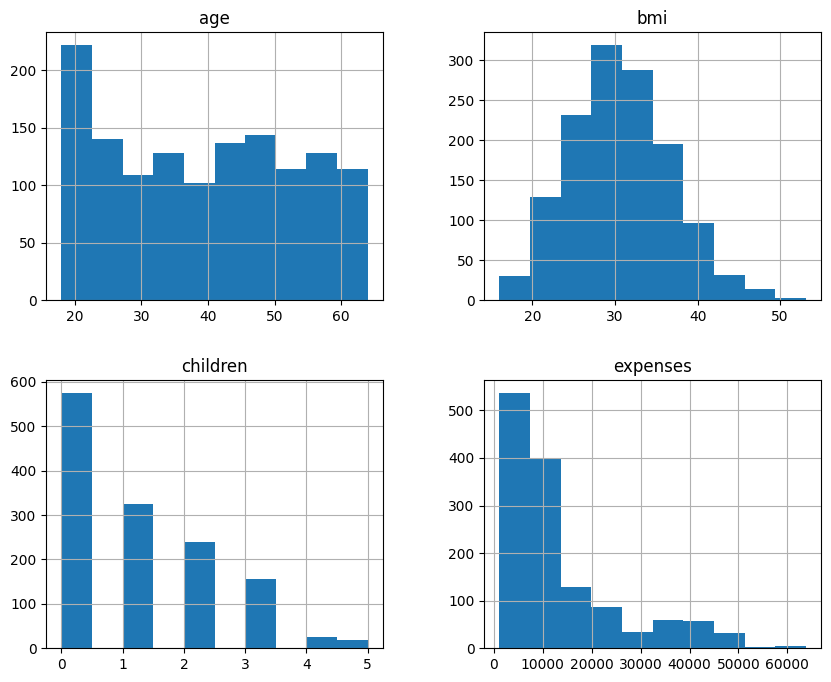

In [17]:
#4
df[['age','bmi','children','expenses']].hist(figsize=(10,8))
plt.show()
# Observation:
# Age is almost uniformly distributed.
# BMI follows a near normal distribution.
# Children are concentrated at lower values.
# Charges are highly right-skewed with some expensive outliers.

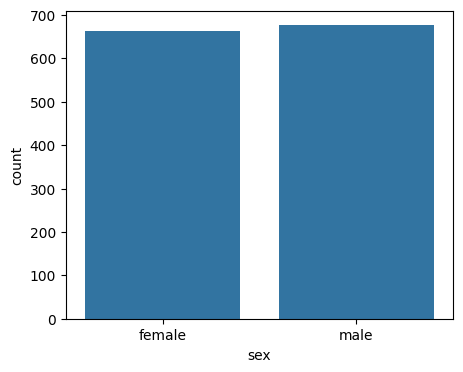

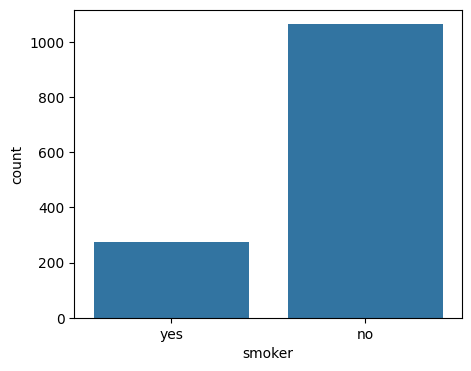

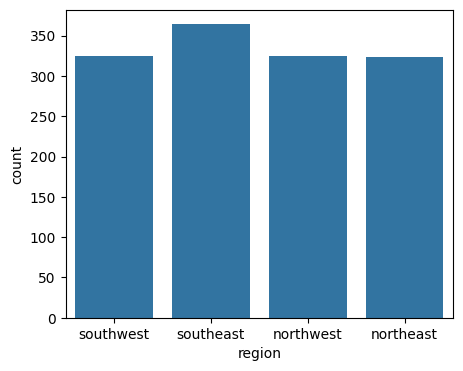

In [25]:
#5
import seaborn as sns
categorical = ['sex','smoker','region']
for col in categorical:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=df)
    plt.show()
# Observation:
# Male and female customers are nearly equal.
# Most customers are non-smokers.
# All regions have a fairly balanced number of customers.

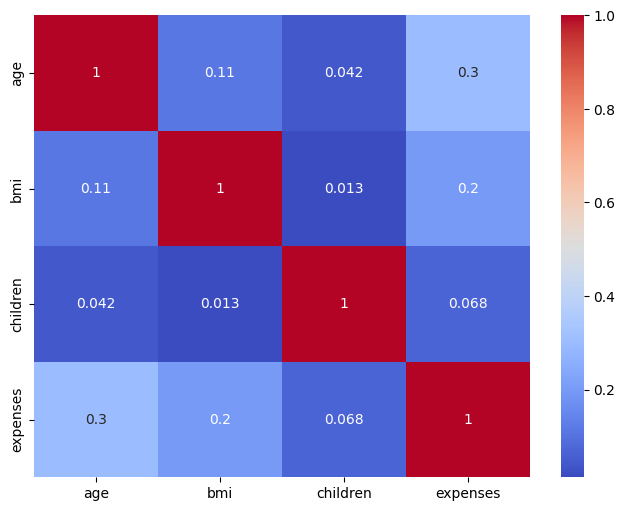

In [26]:
#6
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()
# Observation:
# Charges have a positive correlation with age.
# BMI also has a positive relationship with charges.
# Children have a weak correlation with charges.

In [30]:
#7
df = pd.read_csv("insurance.csv")
X = df.drop("expenses", axis=1)
y = df["expenses"]
print("Independent Features:")
print(X.columns)
print("\nDependent Feature:")
print(y.name)
# Independent Features:age, sex, bmi, children, smoker, region
# Dependent Feature:charges
# Reason:We use customer information to predict medical insurance charges.

Independent Features:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

Dependent Feature:
expenses


In [31]:
#8
print(df[['sex','smoker']].head())
encoded_df = pd.get_dummies(df, drop_first=True)
print(encoded_df.head())


      sex smoker
0  female    yes
1    male     no
2    male     no
3    male     no
4    male     no
   age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0  16884.92     False        True             False   
1   18  33.8         1   1725.55      True       False             False   
2   28  33.0         3   4449.46      True       False             False   
3   33  22.7         0  21984.47      True       False              True   
4   32  28.9         0   3866.86      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [32]:
#9
from sklearn.preprocessing import StandardScaler
features = ['age','bmi','children']
scaler = StandardScaler()
scaled = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled, columns=features)
print(scaled_df.head())


        age       bmi  children
0 -1.438764 -0.453646 -0.908614
1 -1.509965  0.514186 -0.078767
2 -0.797954  0.382954  1.580926
3 -0.441948 -1.306650 -0.908614
4 -0.513149 -0.289606 -0.908614


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


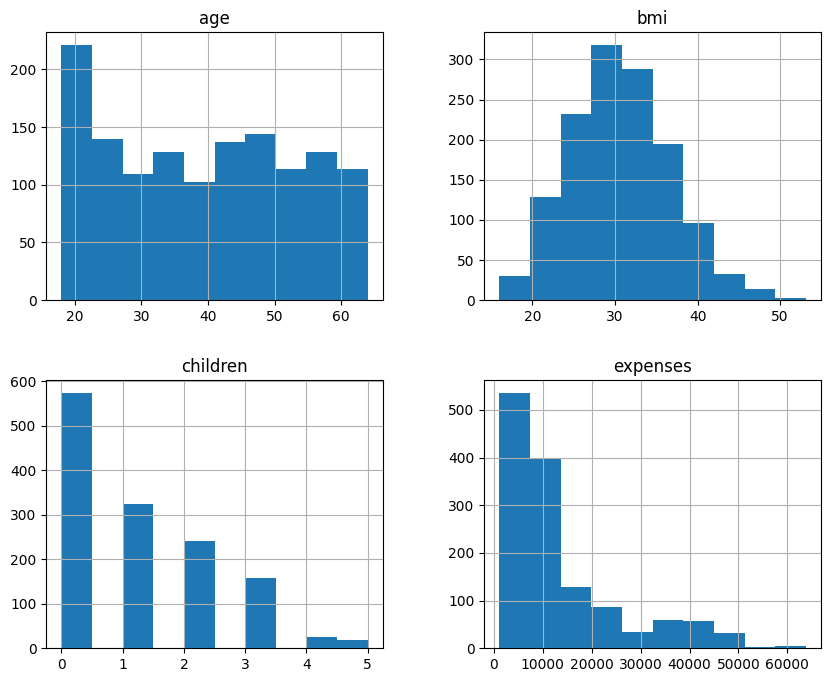

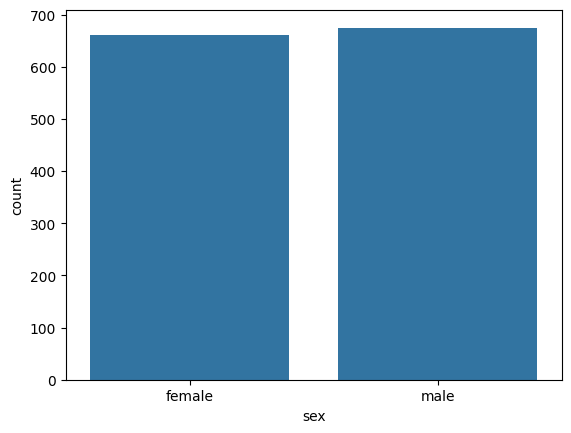

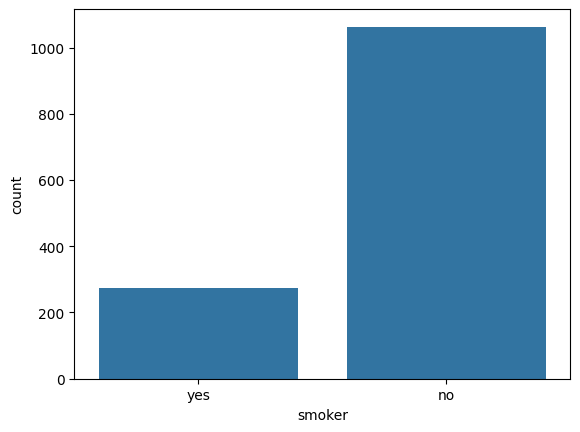

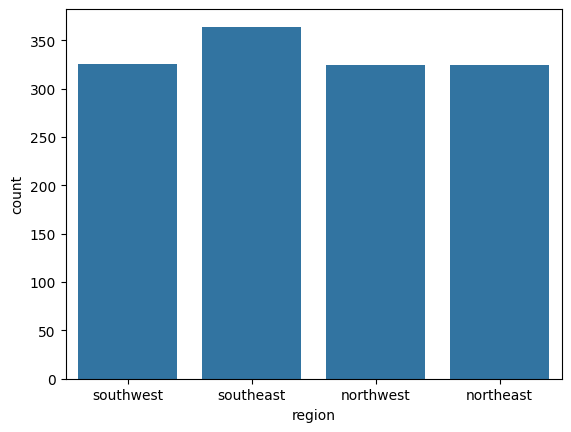

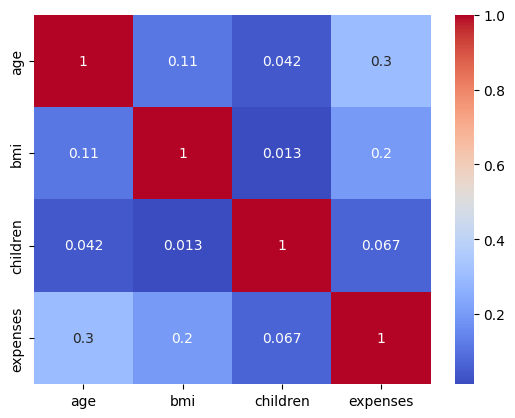

Input Features:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')
Output Feature:
expenses
        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.440418 -0.453484 -0.909234     False        True             False   
1 -1.511647  0.513986 -0.079442      True       False             False   
2 -0.799350  0.382803  1.580143      True       False             False   
3 -0.443201 -1.306169 -0.909234      True       False              True   
4 -0.514431 -0.289506 -0.909234      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [57]:
print(df.isnull().sum())
df = df.drop_duplicates()
df[['age', 'bmi', 'children', 'expenses']].hist(figsize=(10,8))
plt.show()
sns.countplot(x='sex', data=df)
plt.show()
sns.countplot(x='smoker', data=df)
plt.show()
sns.countplot(x='region', data=df)
plt.show()
sns.heatmap(df[['age', 'bmi', 'children', 'expenses']].corr(),annot=True,cmap='coolwarm')
plt.show()

X = df.drop('expenses', axis=1)
y = df['expenses']
print("Input Features:")
print(X.columns)
print("Output Feature:")
print(y.name)
X = pd.get_dummies(X, drop_first=True)
numeric_features = ['age', 'bmi', 'children']
X[numeric_features] = scaler.fit_transform(X[numeric_features])
print(X.head())